# Personalized Career Recommendation System — Exploratory Data Analysis

**Dataset:** `personalized/data/career_dataset.csv`  
IT career profiles used by the recommendation engine (TF–IDF + interest overlap + cosine similarity).

**Goals**
1. Explore and clean the data
2. Understand career label distribution
3. Analyze skills and interests used for matching
4. Create charts for the project report


## 1. Setup & Imports

In [1]:
import os
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

FIG_DIR = Path("figures") / "eda"
if not FIG_DIR.exists():
    FIG_DIR = Path("..") / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches="tight", dpi=120)
    print("Saved:", path.resolve())

## 2. Load the Data

In [2]:
CANDIDATES = [
    os.path.join("personalized", "data", "career_dataset.csv"),
    os.path.join("data", "career_dataset.csv"),
    os.path.join("..", "personalized", "data", "career_dataset.csv"),
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("career_dataset.csv not found. Open notebook from project root.")

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print("Path :", os.path.abspath(DATA_PATH))
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Path : C:\Personalized-Career-Recommendation-system\personalized\data\career_dataset.csv
Shape: (15100, 6)
Columns: ['Name', 'Strength', 'Education', 'Skills', 'Interests', 'Recommended_Career']


,Name,Strength,Education,Skills,Interests,Recommended_Career
0,Pamela Garcia,10+ years of professional experience,Bachelor's in Journalism,"docs-as-code, swagger, openapi, api documentation, technical writing, conflu...","Technical Writing, Docs-as-Code and Swagger/OpenAPI, eager to grow within a ...",Technical Writer
1,Kimberly Smith,1 year of professional experience,Bachelor's in Computer Science,"responsive design, plugin development, wordpress, css, theme development, ph...","CSS, Web Developer, responsive design, plugin development, wordpress",Web Developer
2,Tracy Jones,7 years of professional experience,Bachelor's in Software Engineering,"node.js, php, javascript, laravel, typescript, sql","building high-quality solutions, Node, Vue.js Developer, node.js, php, javas...",Vue.js Developer
3,Jody Silva,1 year of professional experience,Bachelor's in Computer Engineering,"JavaScript, Magento, HTML, PHP, Theme Development, WordPress, Plugin Develop...","WordPress Developer, JavaScript, Magento, HTML",WordPress Developer
4,Norman Rangel,Fresher / No prior experience,Currently pursuing Bachelor's in Computer Science,"Research, Problem Solving, CSS, Python, Git, Basic Networking, Teamwork","React Intern, Research, Problem Solving, CSS",React Intern


In [3]:
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 15100 entries, 0 to 15099
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Name                15100 non-null  str  
 1   Strength            15100 non-null  str  
 2   Education           15100 non-null  str  
 3   Skills              15100 non-null  str  
 4   Interests           15100 non-null  str  
 5   Recommended_Career  15100 non-null  str  
dtypes: str(6)
memory usage: 707.9 KB


,count,unique,top,freq
Name,15100,12831,Candidate,1134
Strength,15100,127,10+ years of professional experience,1635
Education,15100,73,Bachelor's in Computer Engineering,2187
Skills,15100,14044,"flutter, dart, firebase, rest api",92
Interests,15100,13907,"Flutter Developer, flutter, dart, firebase",93
Recommended_Career,15100,151,Technical Writer,100


## 3. Data Cleaning

Check missing values, duplicates, and derive numeric features for plots.

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nMissing %:")
print((df.isna().mean() * 100).round(2))
print(f"\nFully duplicate rows: {df.duplicated().sum()}")
print("Empty Skills:", (df["Skills"].fillna("").astype(str).str.strip() == "").sum())
print("Empty Recommended_Career:", (df["Recommended_Career"].fillna("").astype(str).str.strip() == "").sum())

Missing values per column:
Name                  0
Strength              0
Education             0
Skills                0
Interests             0
Recommended_Career    0
dtype: int64

Missing %:
Name                  0.0
Strength              0.0
Education             0.0
Skills                0.0
Interests             0.0
Recommended_Career    0.0
dtype: float64

Fully duplicate rows: 98
Empty Skills: 0
Empty Recommended_Career: 0


In [5]:
def count_items(text):
    parts = re.split(r"[,;]+", str(text or ""))
    return len([p for p in parts if p.strip()])

df["skills_count"] = df["Skills"].apply(count_items)
df["interests_count"] = df["Interests"].apply(count_items)
df["skills_text_len"] = df["Skills"].fillna("").astype(str).str.len()
df["interests_text_len"] = df["Interests"].fillna("").astype(str).str.len()
df[["skills_count", "interests_count", "skills_text_len", "interests_text_len"]].describe()

,skills_count,interests_count,skills_text_len,interests_text_len
count,15100.000000,15100.000000,15100.000000,15100.000000
mean,6.179007,4.640132,75.429934,73.763311
std,1.605572,1.027810,28.712562,32.627933
min,4.000000,4.000000,19.000000,22.000000
25%,5.000000,4.000000,53.000000,48.000000
50%,6.000000,4.000000,73.000000,64.000000
75%,8.000000,5.000000,95.000000,93.000000
max,10.000000,11.000000,176.000000,235.000000


## 4. Target Variable — `Recommended_Career`

### Figure: Top 20 careers & class balance

Unique careers:

 151
Rows per career — min: 100 max: 100 mean: 100.0
Recommended_Career
Technical Writer               100
Web Developer                  100
Vue.js Developer               100
WordPress Developer            100
React Intern                   100
Dynamics 365 Developer         100
Solutions Architect            100
Machine Learning Engineer      100
Python Intern                  100
AWS Engineer                   100
Documentation Engineer         100
Software Engineering Intern    100
Business Analyst               100
Prompt Engineer                100
.NET Developer                 100
Name: count, dtype: int64


Saved: C:\Personalized-Career-Recommendation-system\figures\eda\01_top20_careers.png


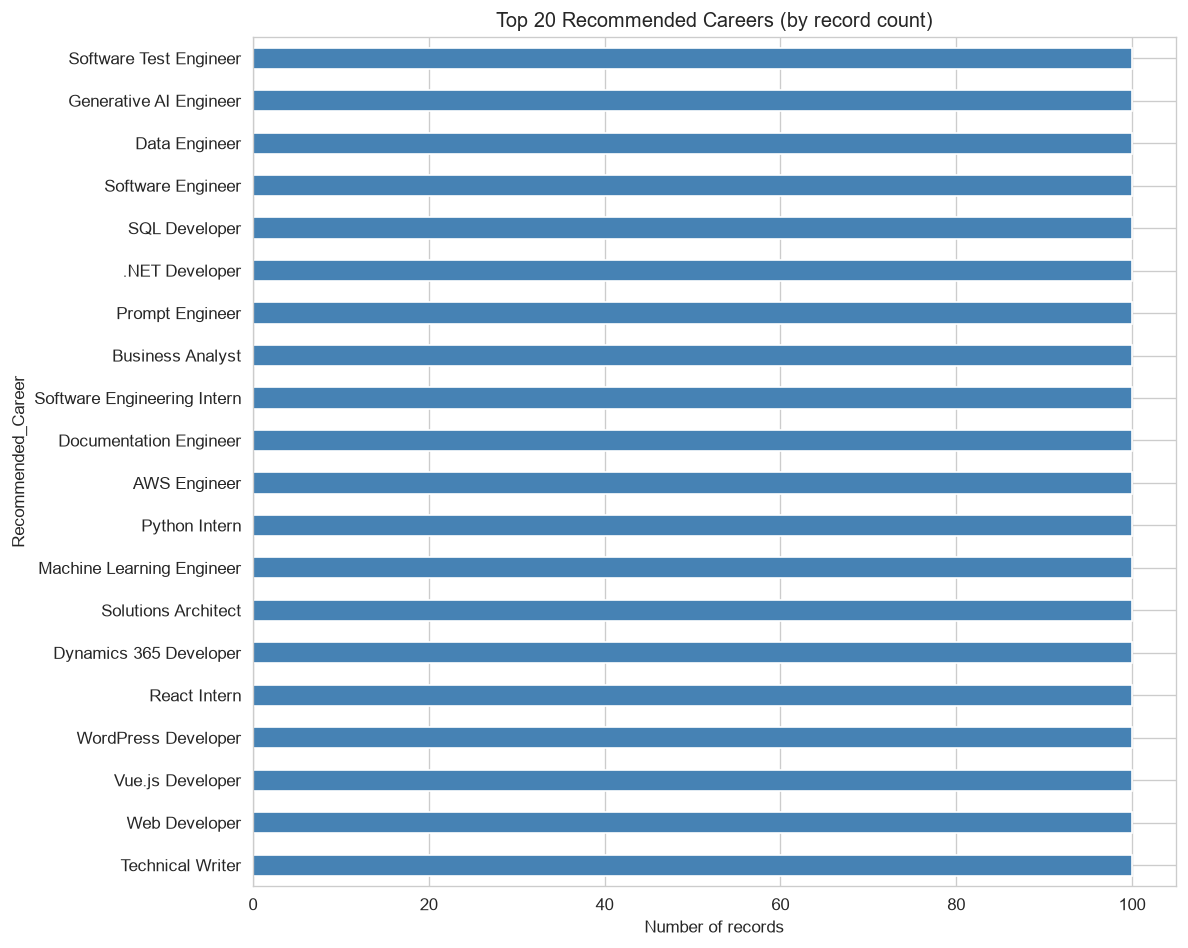

Saved: C:\Personalized-Career-Recommendation-system\figures\eda\02_career_class_balance.png


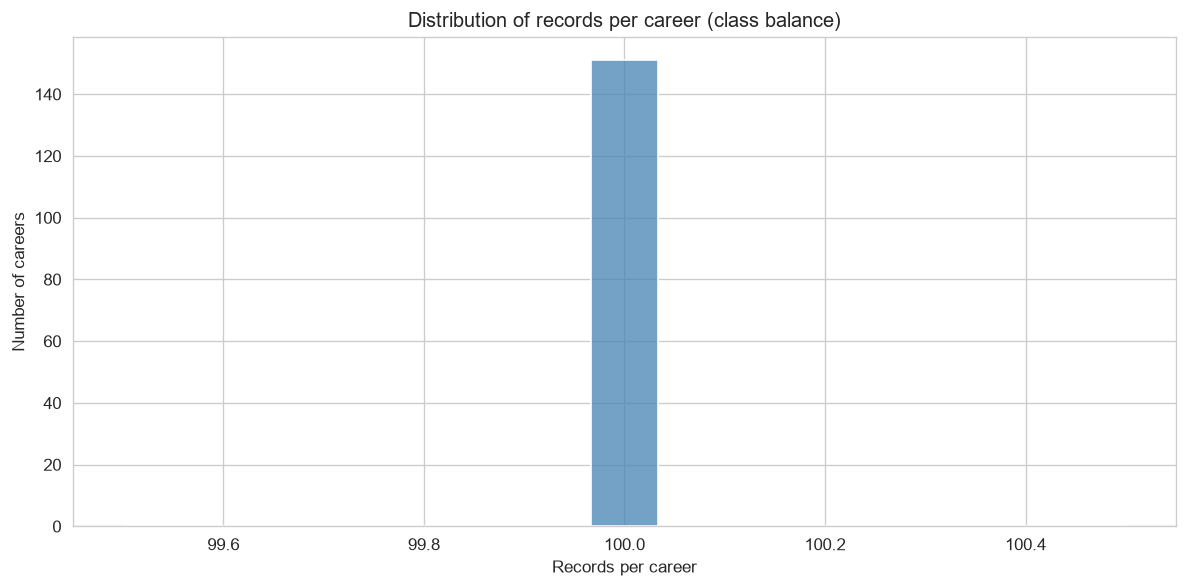

In [6]:
career_counts = df["Recommended_Career"].value_counts()
print("Unique careers:", df["Recommended_Career"].nunique())
print("Rows per career — min:", career_counts.min(), "max:", career_counts.max(), "mean:", round(career_counts.mean(), 1))
print(career_counts.head(15))

plt.figure(figsize=(10, 8))
career_counts.head(20).sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 20 Recommended Careers (by record count)")
plt.xlabel("Number of records")
plt.tight_layout()
savefig("01_top20_careers.png")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(career_counts.values, bins=15, color="steelblue")
plt.title("Distribution of records per career (class balance)")
plt.xlabel("Records per career")
plt.ylabel("Number of careers")
plt.tight_layout()
savefig("02_career_class_balance.png")
plt.show()


## 5. Numeric Feature Exploration

### Figure: skills/interests counts and text lengths

Saved: C:\Personalized-Career-Recommendation-system\figures\eda\03_numeric_distributions.png


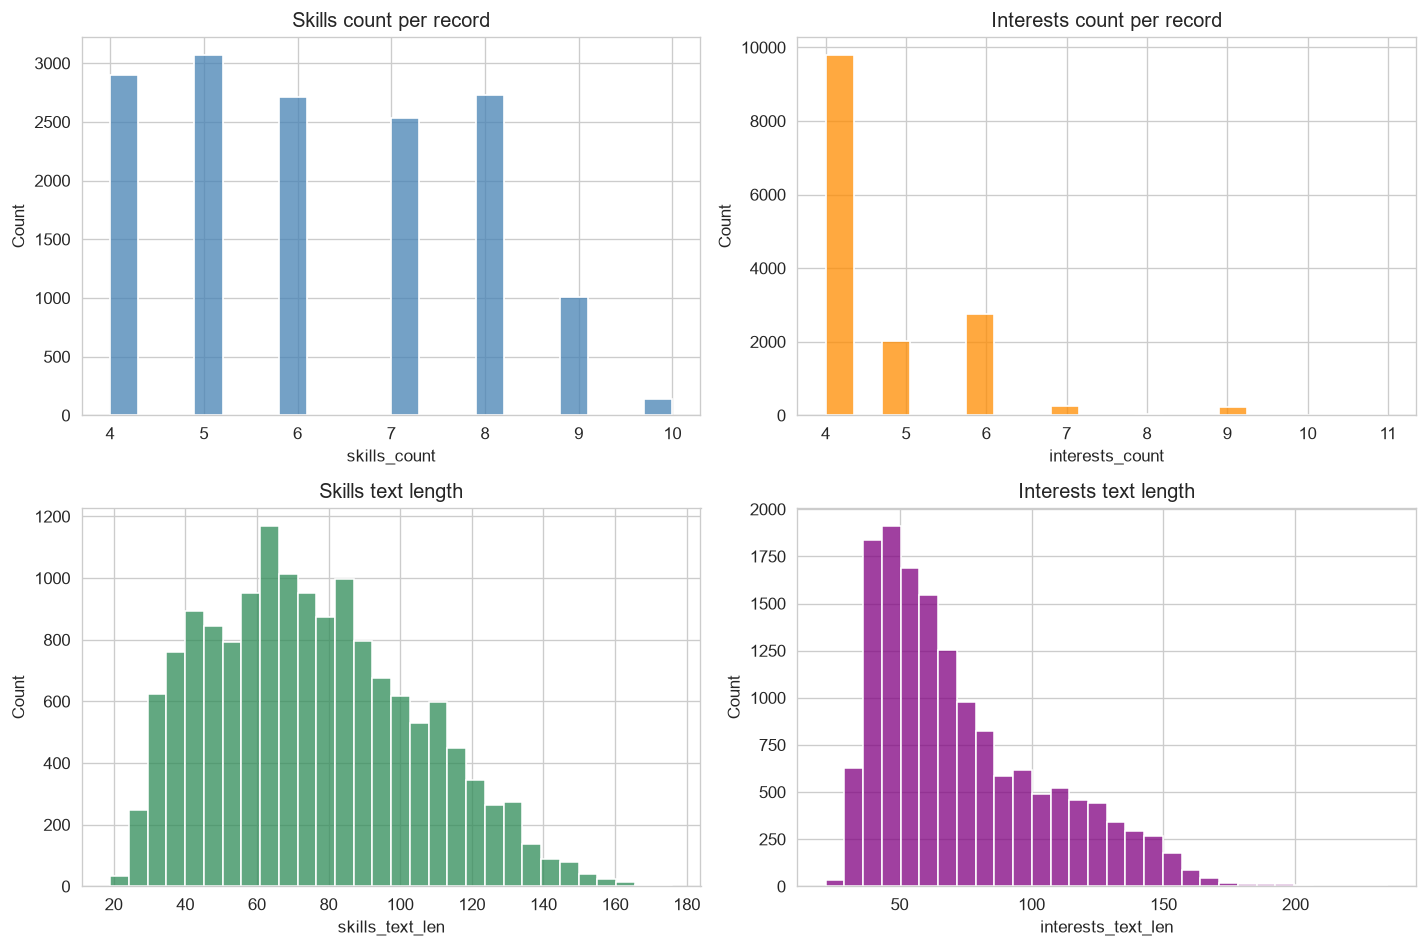

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["skills_count"], bins=20, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Skills count per record")
sns.histplot(df["interests_count"], bins=20, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Interests count per record")
sns.histplot(df["skills_text_len"], bins=30, ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Skills text length")
sns.histplot(df["interests_text_len"], bins=30, ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Interests text length")
plt.tight_layout()
savefig("03_numeric_distributions.png")
plt.show()

## 6. Education & Strength

### Figures: top education and strength labels

Top education values:
Education
Bachelor's in Computer Engineering                         2187
Bachelor's in Computer Science                             1837
Bachelor's in Information Technology                       1813
Master's in Computer Science                                451
Bachelor's in Business Administration                       440
Diploma in Computer Networking                              367
Currently pursuing Bachelor's in Information Technology     362
Final year Bachelor's student                               355
Currently pursuing Bachelor's in Computer Engineering       346
CCNA Certification                                          342
Currently pursuing Bachelor's in Computer Science           337
Bachelor's in Software Engineering                          287
Bachelor's in Statistics                                    237
Master's in Artificial Intelligence                         232
Master's in Information Security                            222
Name: co

Saved: C:\Personalized-Career-Recommendation-system\figures\eda\04_top_education.png


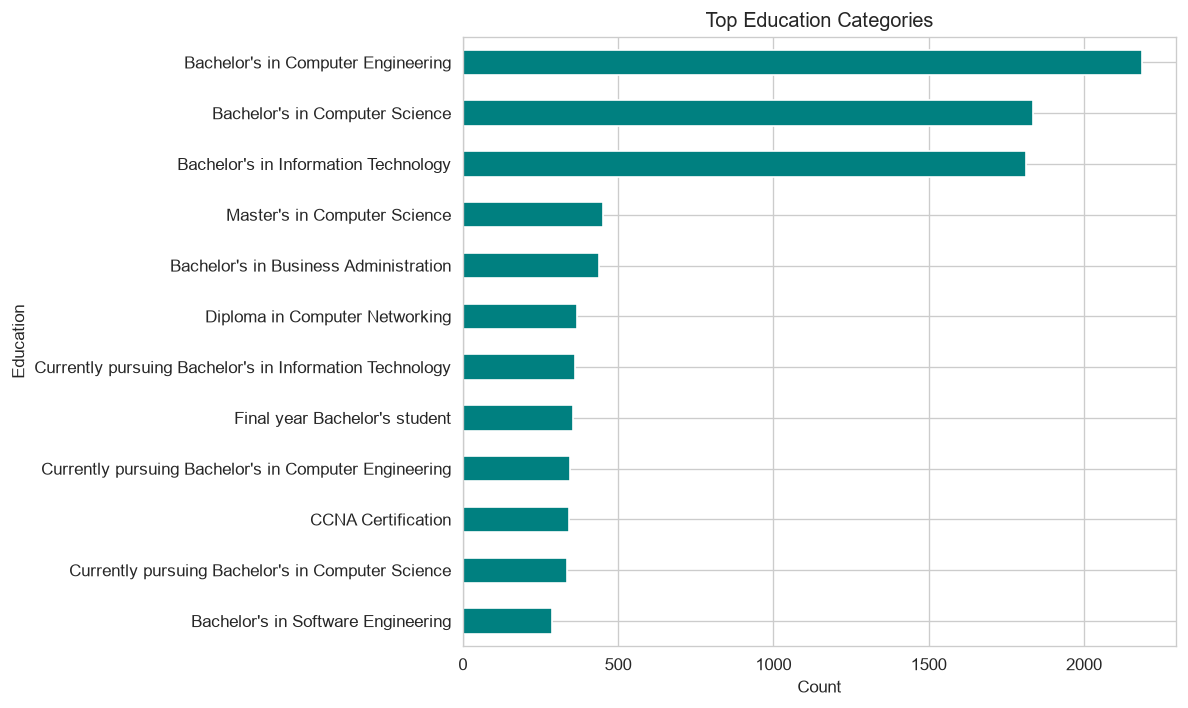


Top Strength / experience values:
Strength
10+ years of professional experience    1635
1 year of professional experience       1616
3 years of professional experience      1579
5 years of professional experience      1572
4 years of professional experience      1547
6 months of internship experience       1536
2 years of professional experience      1531
Fresher / No prior experience           1526
7 years of professional experience      1420
2 years at eSewa                          24
6 years at F1Soft                         22
3 years at CloudFactory                   22
8 years at Deerwalk                       21
5 years at Cotiviti Nepal                 20
6 years at Khalti                         20
Name: count, dtype: int64


Saved: C:\Personalized-Career-Recommendation-system\figures\eda\05_top_strength.png


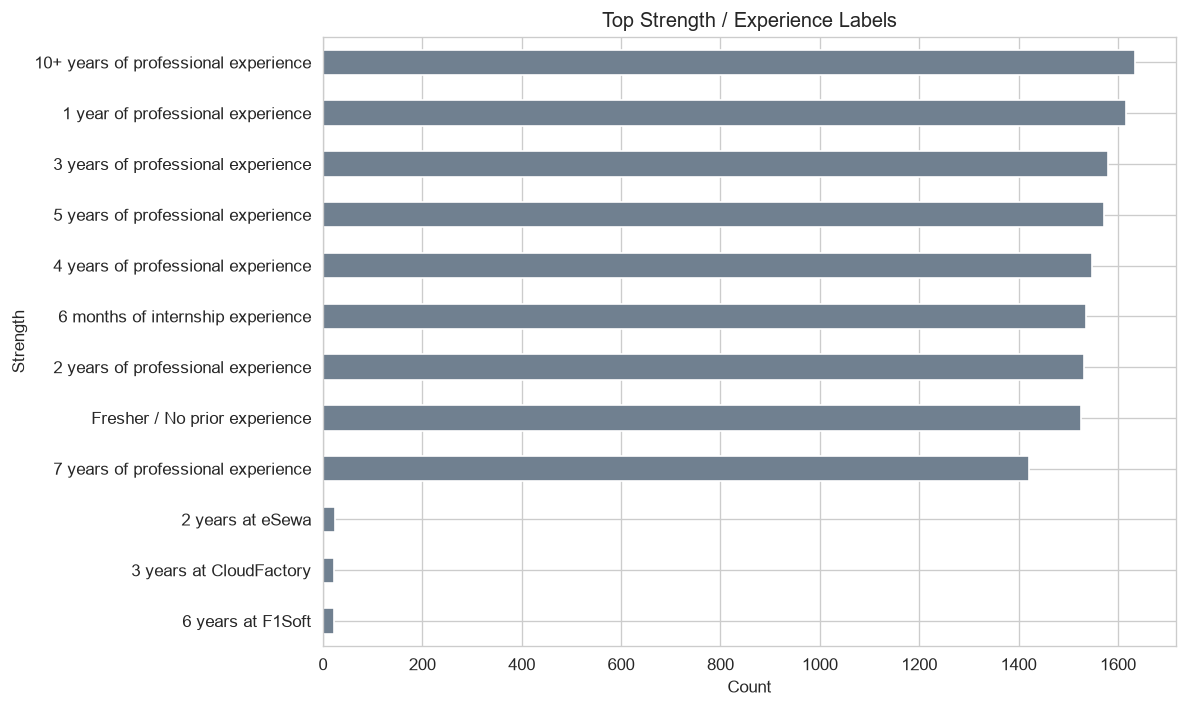

In [8]:
print("Top education values:")
print(df["Education"].value_counts().head(15))

plt.figure(figsize=(10, 6))
df["Education"].value_counts().head(12).sort_values().plot(kind="barh", color="teal")
plt.title("Top Education Categories")
plt.xlabel("Count")
plt.tight_layout()
savefig("04_top_education.png")
plt.show()

print("\nTop Strength / experience values:")
print(df["Strength"].value_counts().head(15))

plt.figure(figsize=(10, 6))
df["Strength"].value_counts().head(12).sort_values().plot(kind="barh", color="slategray")
plt.title("Top Strength / Experience Labels")
plt.xlabel("Count")
plt.tight_layout()
savefig("05_top_strength.png")
plt.show()

## 7. Skills Text Analysis

### Figure: Top 20 technical skills (TF–IDF input)

Total skill token occurrences: 93303
Unique skill tokens: 293
  python: 2267
  sql: 2253
  git: 1582
  javascript: 1468
  java: 1246
  microservices: 1120
  docker: 1054
  linux: 1003
  css: 945
  html: 942
  agile: 903
  stakeholder management: 836
  jira: 743
  team leadership: 717
  django: 715
  budgeting: 698
  confluence: 686
  active directory: 659
  communication: 657
  php: 651
  linux basics: 651
  teamwork: 650
  server maintenance: 650
  vpn: 649
  hardware troubleshooting: 641


Saved: C:\Personalized-Career-Recommendation-system\figures\eda\06_top20_skills.png


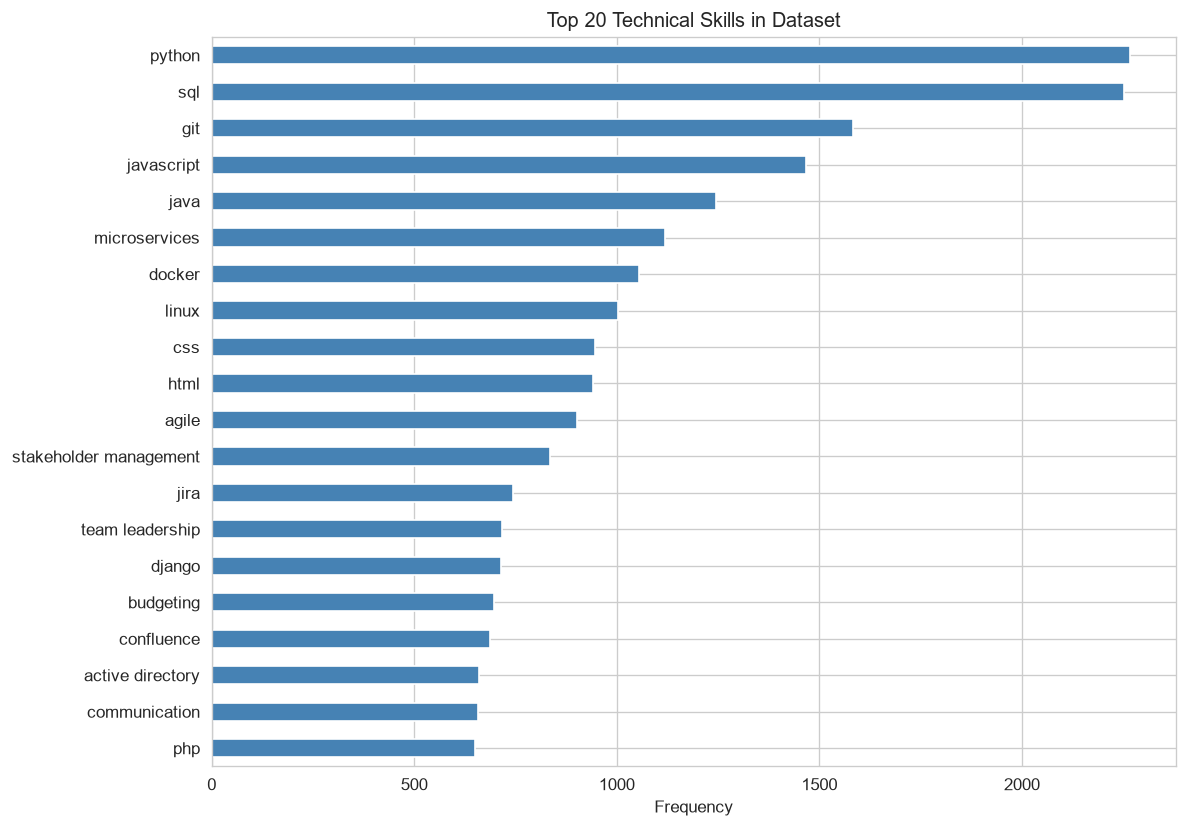

In [9]:
def tokenize_list(series):
    tokens = []
    for text in series.fillna("").astype(str):
        for part in re.split(r"[,;]+", text):
            tok = part.strip().lower()
            if len(tok) >= 2:
                tokens.append(tok)
    return tokens

skill_tokens = tokenize_list(df["Skills"])
skill_counts = Counter(skill_tokens)
print("Total skill token occurrences:", len(skill_tokens))
print("Unique skill tokens:", len(skill_counts))
for skill, cnt in skill_counts.most_common(25):
    print(f"  {skill}: {cnt}")

plt.figure(figsize=(10, 7))
pd.Series(dict(skill_counts.most_common(20))).sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 20 Technical Skills in Dataset")
plt.xlabel("Frequency")
plt.tight_layout()
savefig("06_top20_skills.png")
plt.show()

## 8. Interests Text Analysis

### Figure: Top 20 interest tokens

Total interest token occurrences: 70066
Unique interest tokens: 2721
  building high-quality solutions: 1491
  python: 1382
  eager to grow within a dynamic team: 1343
  sql: 1130
  seeking to contribute to innovative projects: 1026
  javascript: 831
  git: 701
  java: 635
  microservices: 580
  linux: 547
  html: 537
  django: 502
  docker: 475
  css: 440
  agile: 426
  stakeholder management: 407
  react: 403
  jira: 373
  php: 366
  budgeting: 364
  team leadership: 345
  teamwork: 343
  communication: 334
  linux basics: 329
  basic networking: 328


Saved: C:\Personalized-Career-Recommendation-system\figures\eda\07_top20_interests.png


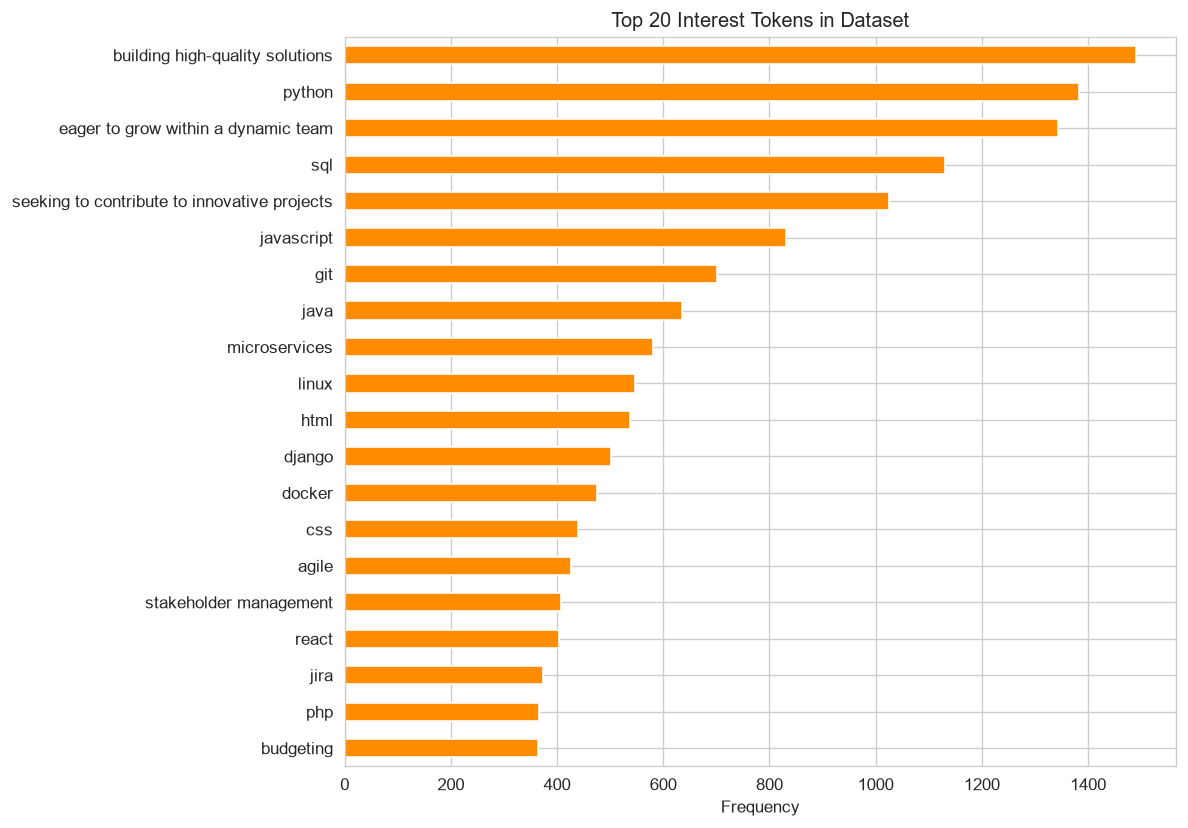

In [10]:
interest_tokens = tokenize_list(df["Interests"])
interest_counts = Counter(interest_tokens)
print("Total interest token occurrences:", len(interest_tokens))
print("Unique interest tokens:", len(interest_counts))
for item, cnt in interest_counts.most_common(25):
    print(f"  {item}: {cnt}")

plt.figure(figsize=(10, 7))
pd.Series(dict(interest_counts.most_common(20))).sort_values().plot(kind="barh", color="darkorange")
plt.title("Top 20 Interest Tokens in Dataset")
plt.xlabel("Frequency")
plt.tight_layout()
savefig("07_top20_interests.png")
plt.show()

## 9. Correlation, Scatter & Boxplot

### Figures: heatmap, scatter, skills by career

Saved: C:\Personalized-Career-Recommendation-system\figures\eda\08_correlation_heatmap.png


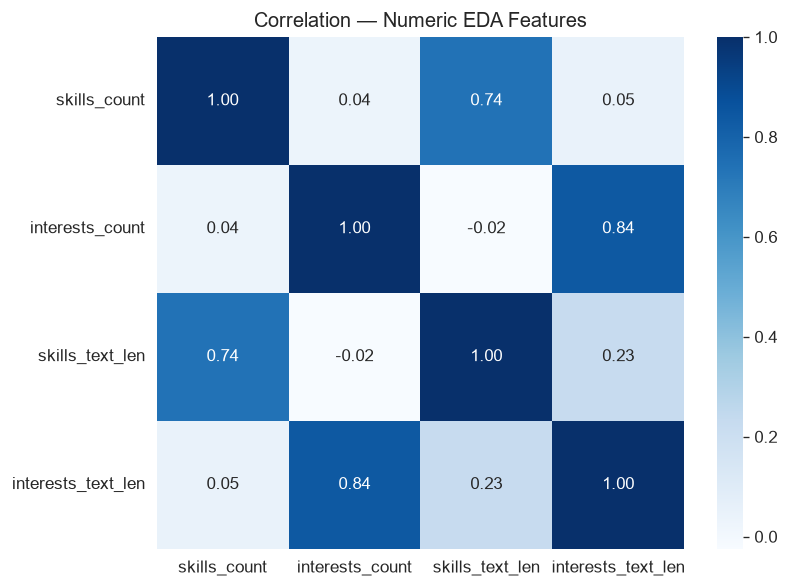

Saved: C:\Personalized-Career-Recommendation-system\figures\eda\09_skills_vs_interests_scatter.png


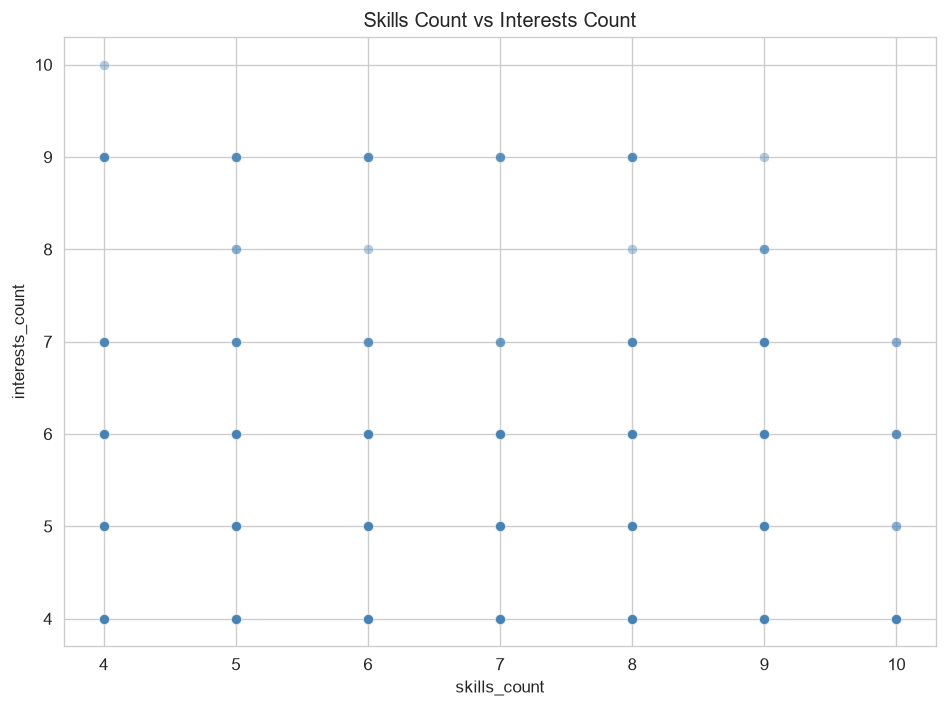

Saved: C:\Personalized-Career-Recommendation-system\figures\eda\10_skills_boxplot_by_career.png


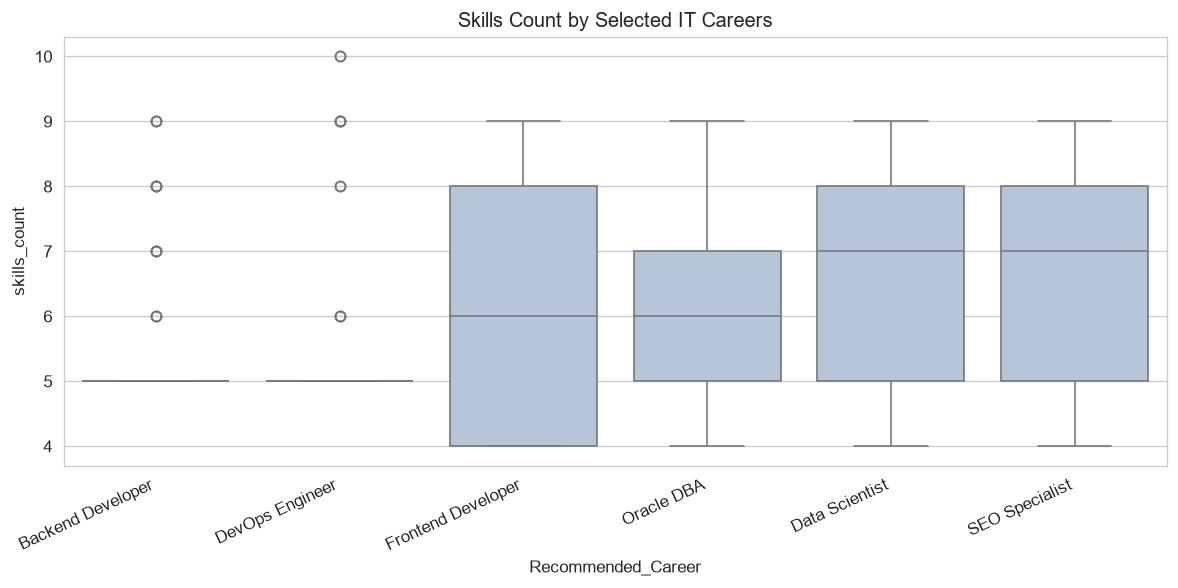

In [11]:
num_cols = ["skills_count", "interests_count", "skills_text_len", "interests_text_len"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation — Numeric EDA Features")
plt.tight_layout()
savefig("08_correlation_heatmap.png")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df.sample(min(2000, len(df)), random_state=42),
    x="skills_count",
    y="interests_count",
    alpha=0.4,
    color="steelblue",
)
plt.title("Skills Count vs Interests Count")
plt.tight_layout()
savefig("09_skills_vs_interests_scatter.png")
plt.show()

focus = [
    "Frontend Developer", "Backend Developer", "Data Scientist",
    "SEO Specialist", "Oracle DBA", "DevOps Engineer",
]
present = []
for name in focus:
    hit = df[df["Recommended_Career"].str.lower() == name.lower()]
    if len(hit):
        present.append(hit["Recommended_Career"].iloc[0])
sub = df[df["Recommended_Career"].isin(present)]
if len(sub):
    plt.figure(figsize=(10, 5))
    order = sub.groupby("Recommended_Career")["skills_count"].median().sort_values().index
    sns.boxplot(data=sub, x="Recommended_Career", y="skills_count", order=order, color="lightsteelblue")
    plt.title("Skills Count by Selected IT Careers")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    savefig("10_skills_boxplot_by_career.png")
    plt.show()

## 10. Figure Gallery

All charts saved under `figures/eda/`.


Found 10 figures in C:\Personalized-Career-Recommendation-system\figures\eda


### 01_top20_careers.png

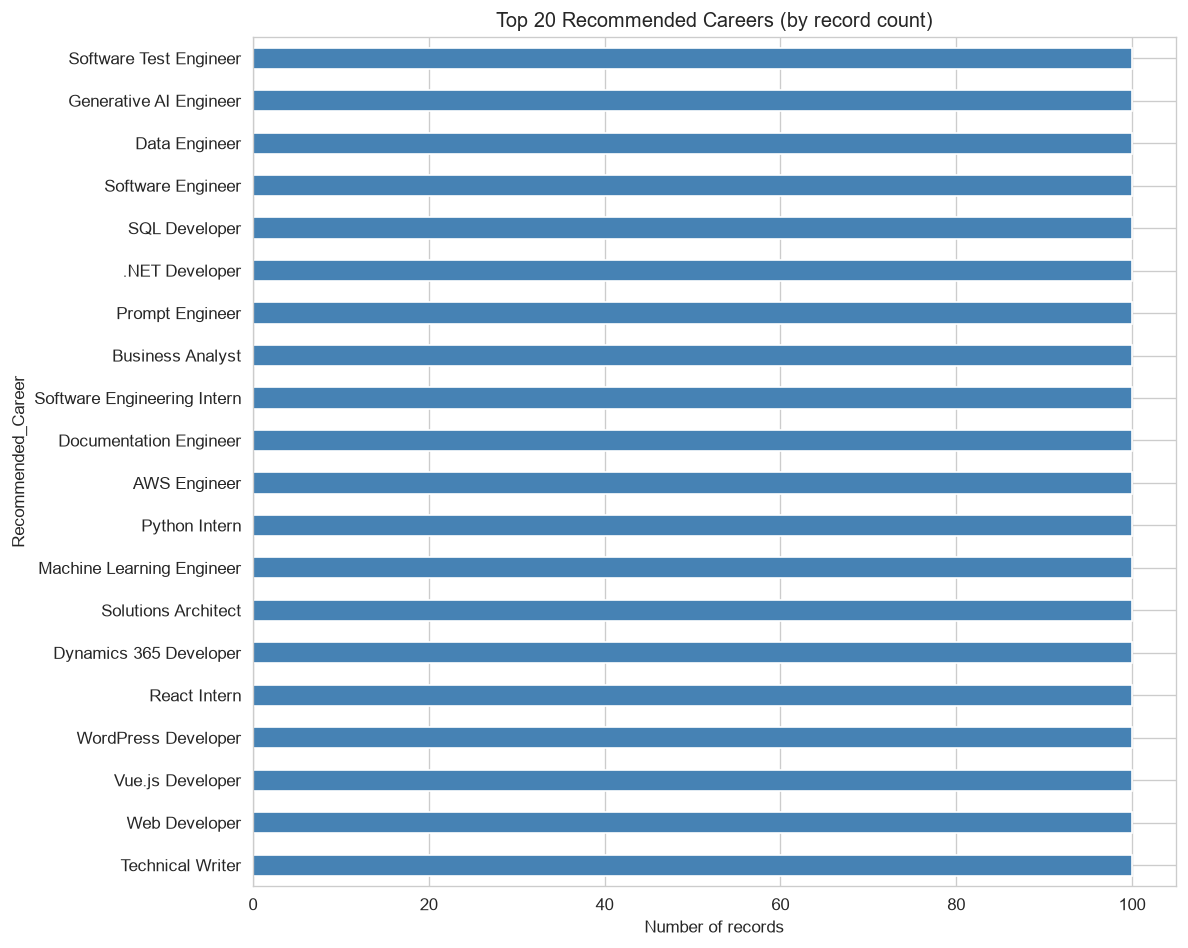

### 02_career_class_balance.png

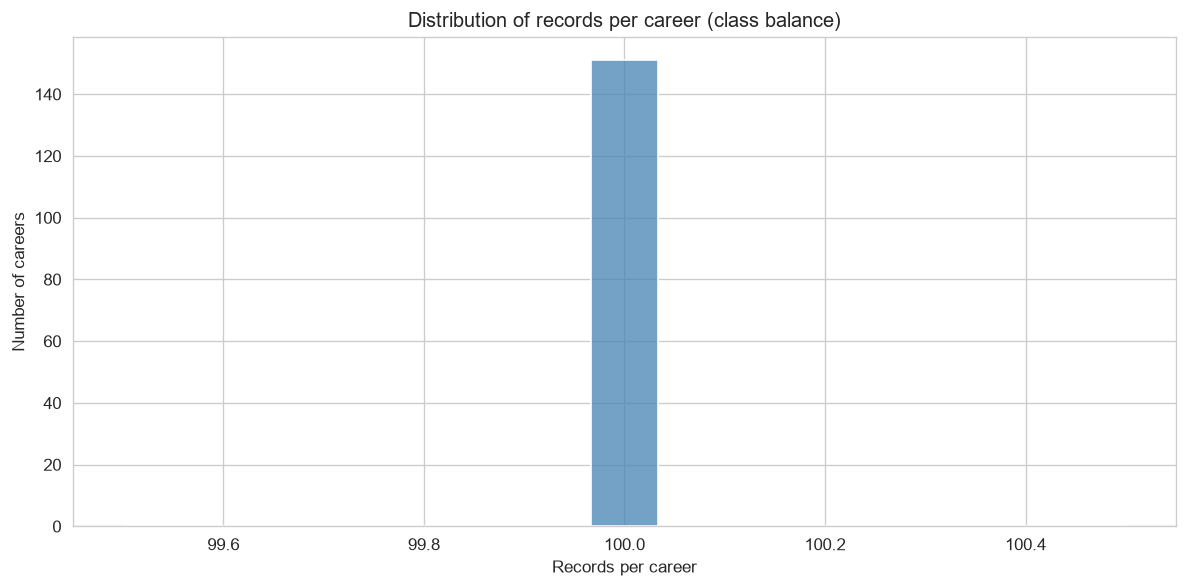

### 03_numeric_distributions.png

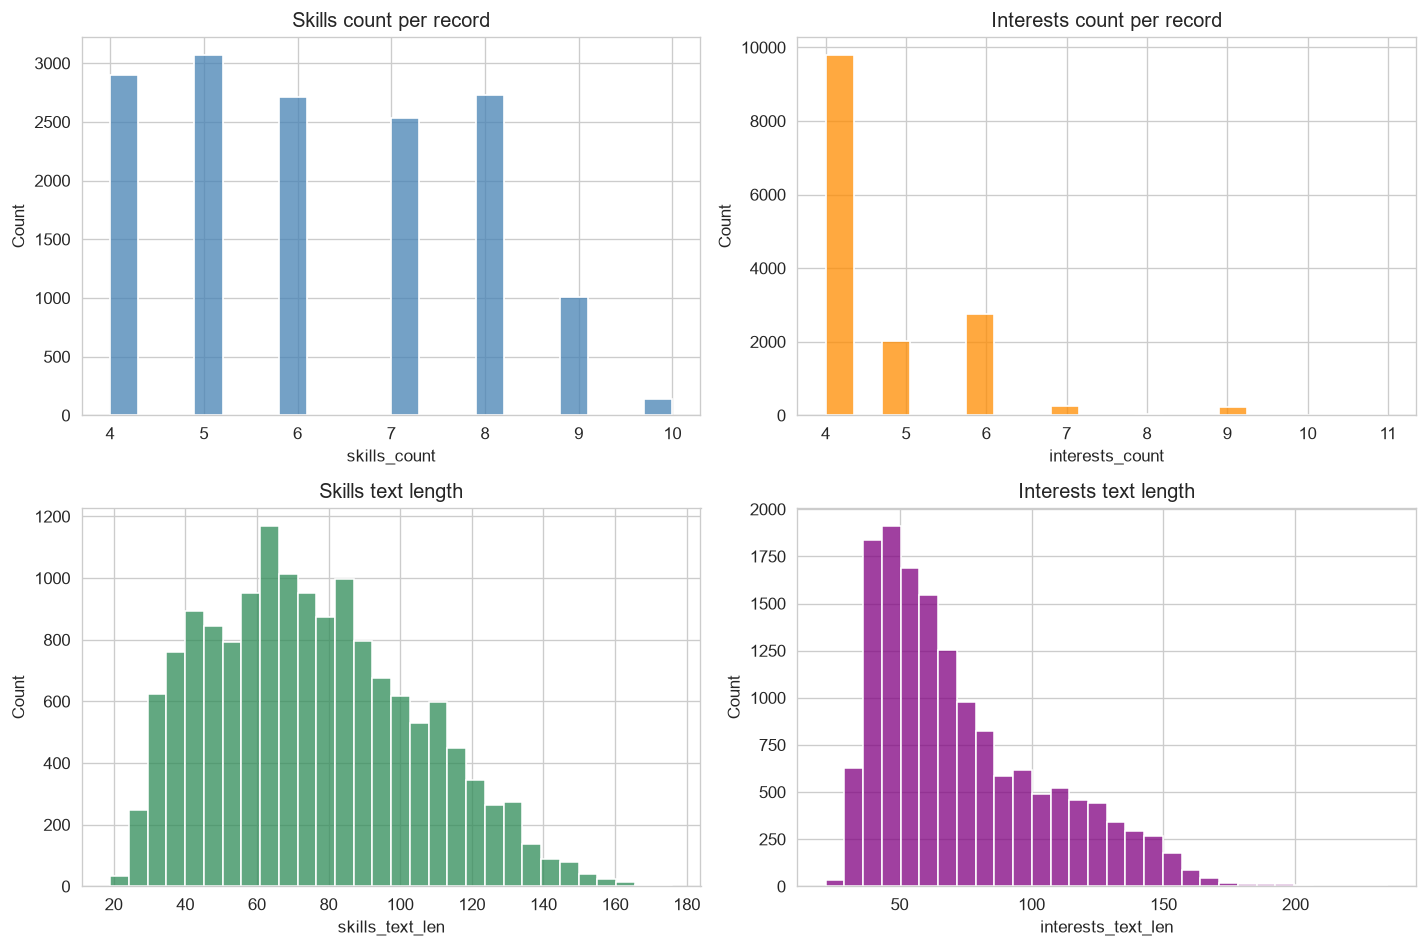

### 04_top_education.png

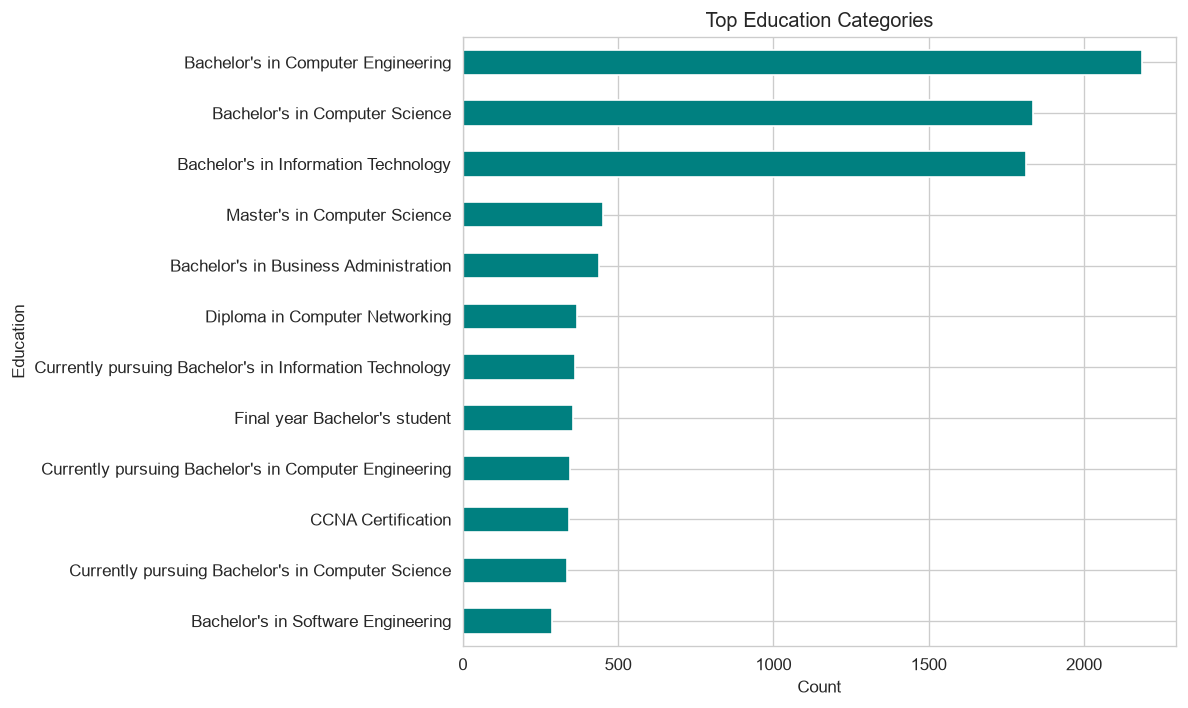

### 05_top_strength.png

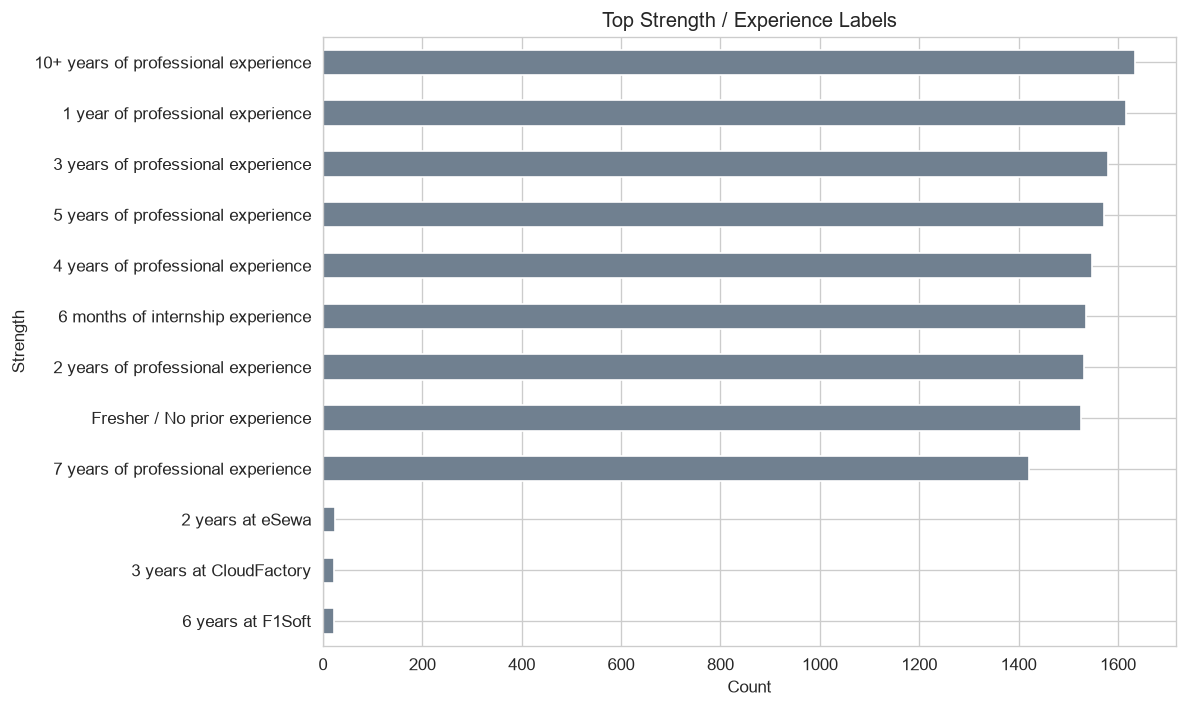

### 06_top20_skills.png

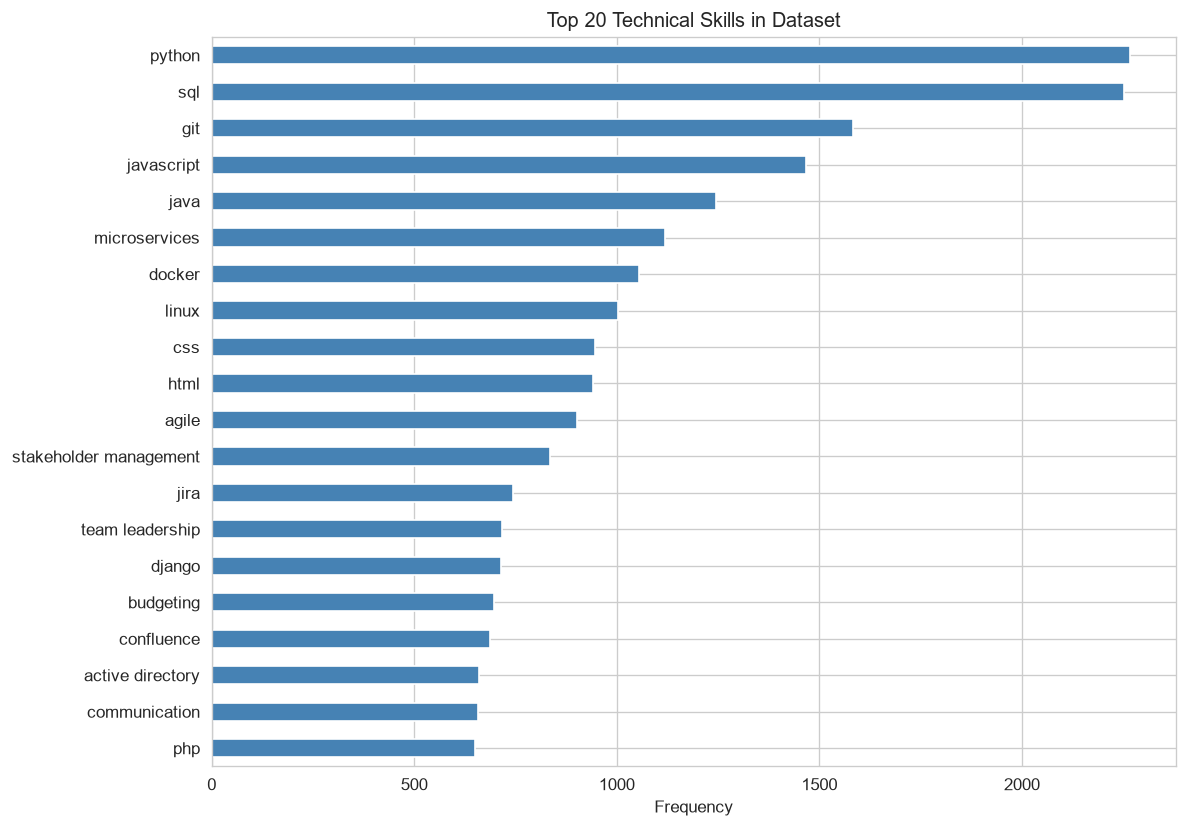

### 07_top20_interests.png

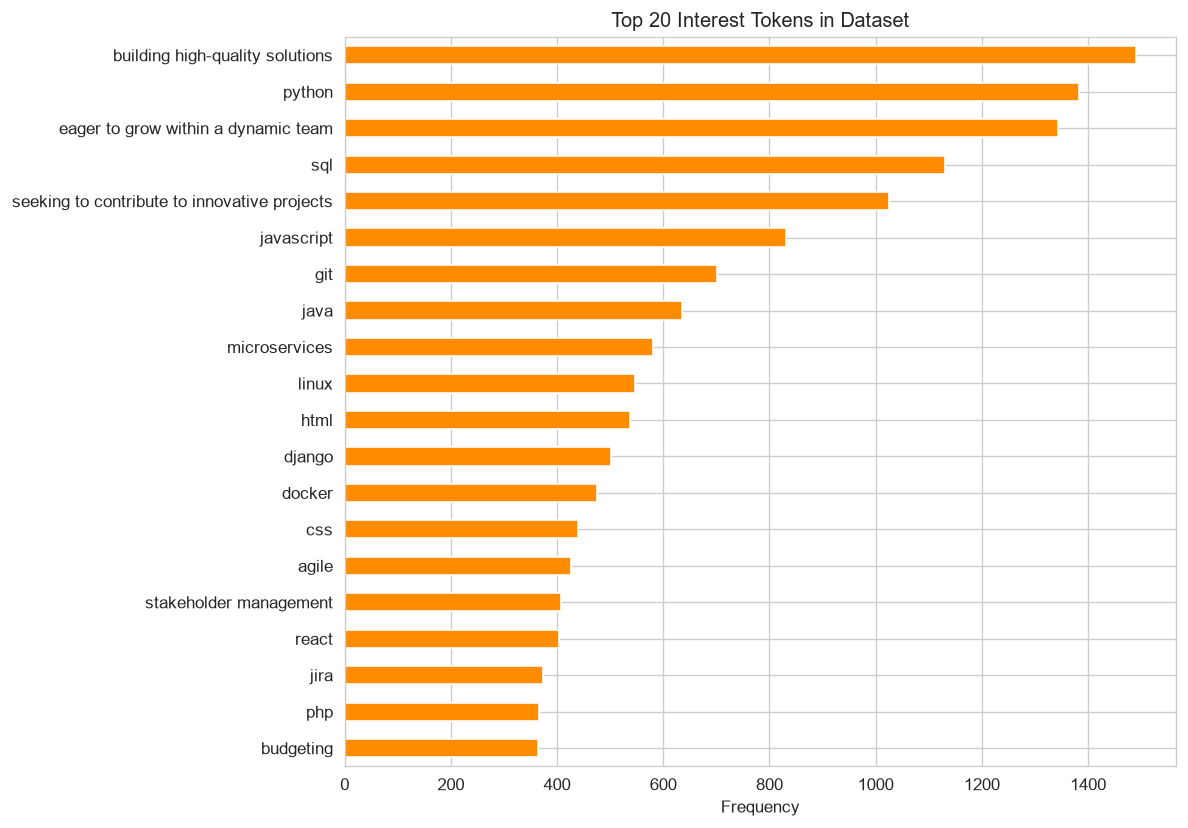

### 08_correlation_heatmap.png

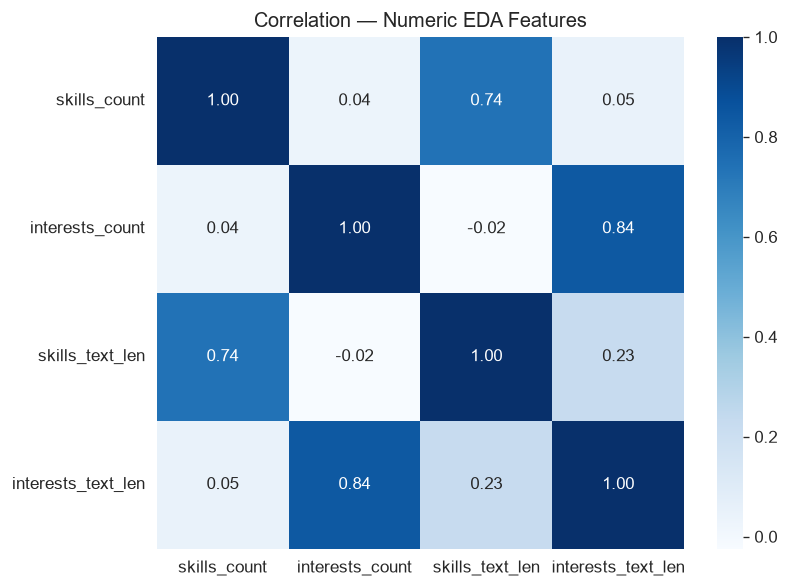

### 09_skills_vs_interests_scatter.png

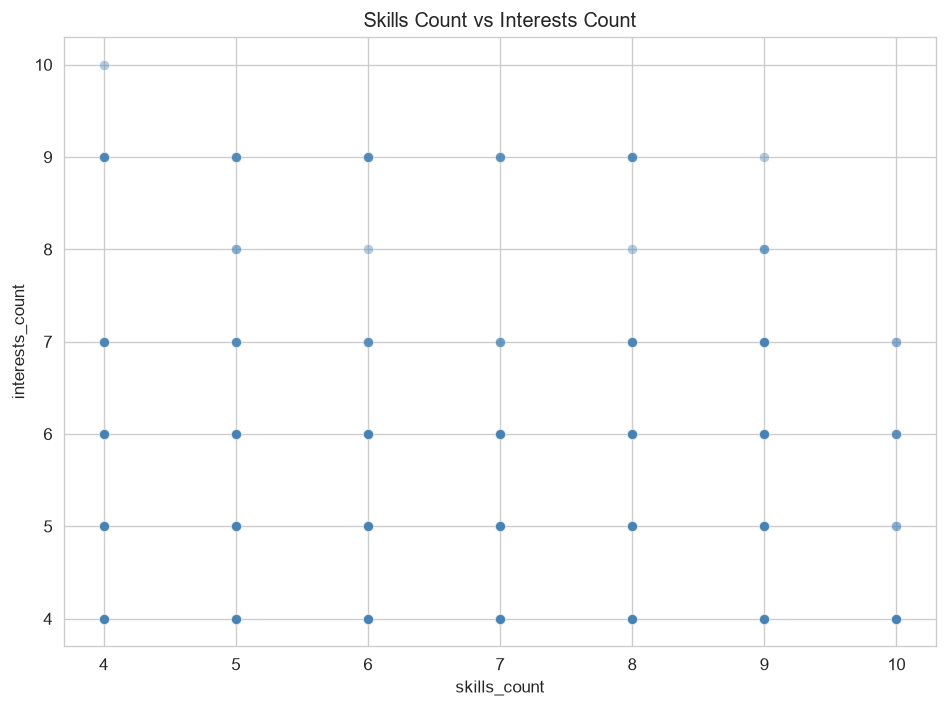

### 10_skills_boxplot_by_career.png

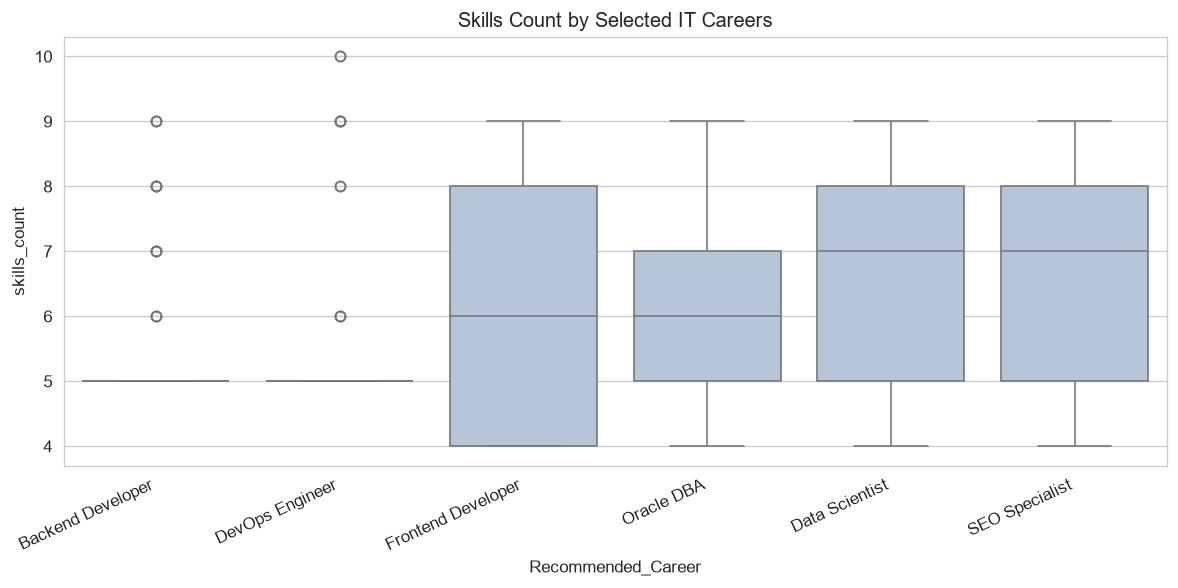

In [12]:
gallery = sorted(FIG_DIR.glob("*.png"))
print(f"Found {len(gallery)} figures in", FIG_DIR.resolve())
for img in gallery:
    display(Markdown(f"### {img.name}"))
    display(Image(filename=str(img)))

## 11. Sample Records (SEO / DBA / Frontend / Data Scientist)

In [13]:
sample_careers = [
    "SEO Specialist", "Oracle DBA", "Database Administrator (DBA)",
    "Frontend Developer", "Data Scientist",
]
for career in sample_careers:
    subset = df[df["Recommended_Career"].str.lower() == career.lower()]
    if subset.empty:
        subset = df[df["Recommended_Career"] == career]
    print("=" * 70)
    print(career, "— rows:", len(subset))
    if len(subset):
        print(subset[["Skills", "Interests", "Education"]].head(2).to_string(index=False))

SEO Specialist — rows: 100
                                                                                                          Skills                                                                   Interests                             Education
social media marketing, google analytics, content marketing, marketing automation, hubspot, email marketing, seo SEO Specialist, social media marketing, google analytics, content marketing Bachelor's in Business Administration
     content marketing, b testing, hubspot, google analytics, crm tools, social media marketing, email marketing                       SEO Specialist, content marketing, b testing, hubspot      Bachelor's in Mass Communication
Oracle DBA — rows: 100
                                                                                                  Skills                                                   Interests                      Education
Backup & Recovery, Oracle Database, Replication, Query Optimization, SQL,

## 12. Summary

- Dataset supports **IT career recommendation** with Skills, Interests, Education, and Recommended_Career.
- Careers are balanced (~100 rows each) — good for Top-1 / Top-3 evaluation.
- Skills (e.g. Python, SQL, JavaScript) feed **TF–IDF**; interests support overlap + cosine.
- Figures are saved in `figures/eda/` for the report and also shown above in this notebook.

**Related files:** `personalized/career.py`, `personalized/formulas.py`, `model_evaluation.ipynb`
